<a href="https://colab.research.google.com/github/OvoFiona/Fraud-Detection/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Libraries and loading dataset
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset from the uploaded CSV file
print("Please upload the 'bank_transaction_data_2.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Please upload the 'bank_transaction_data_2.csv' file:


Saving bank_transactions_data_2.csv to bank_transactions_data_2.csv


In [2]:
#Displaying basic information about the dataset
print("="*50)
print("BASIC DATASET INFORMATION")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

BASIC DATASET INFORMATION
Dataset shape: (2512, 16)
Number of rows: 2512
Number of columns: 16

Column names:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']

Data types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

First 5 rows:
  Transaction

DATA CLEANING

MISSING VALUES CHECK
                         Missing Values  Percentage
TransactionID                         0         0.0
AccountID                             0         0.0
TransactionAmount                     0         0.0
TransactionDate                       0         0.0
TransactionType                       0         0.0
Location                              0         0.0
DeviceID                              0         0.0
IP Address                            0         0.0
MerchantID                            0         0.0
Channel                               0         0.0
CustomerAge                           0         0.0
CustomerOccupation                    0         0.0
TransactionDuration                   0         0.0
LoginAttempts                         0         0.0
AccountBalance                        0         0.0
PreviousTransactionDate               0         0.0


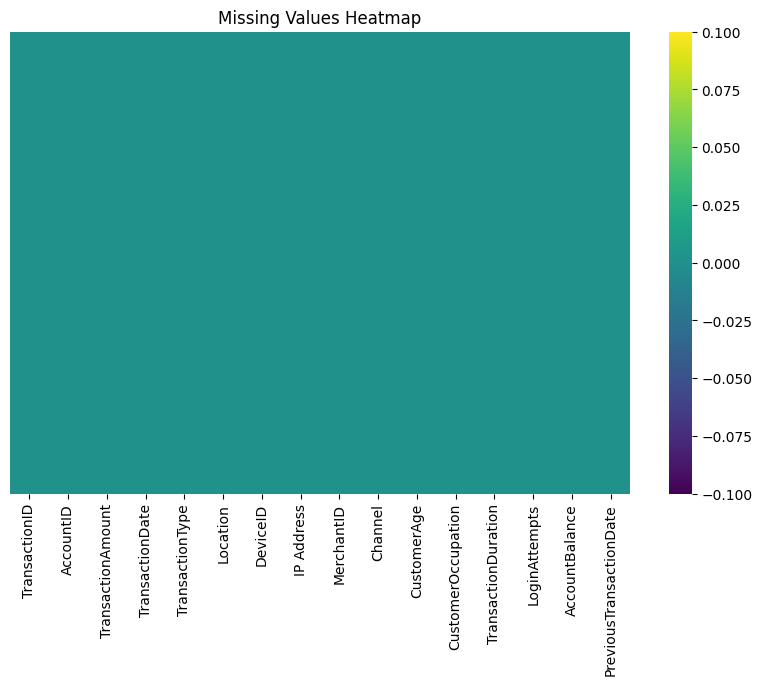

In [3]:
#Check for missing values
print("="*50)
print("MISSING VALUES CHECK")
print("="*50)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df)

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [5]:
#Check for duplicate rows
print("="*50)
print("DUPLICATE ROWS CHECK")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

#Check for duplicate transactions
duplicate_transactions = df.duplicated(subset=['TransactionID']).sum()
print(f"Duplicate Transaction IDs: {duplicate_transactions}")

#If duplicates exist, remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

DUPLICATE ROWS CHECK
Number of duplicate rows: 0
Duplicate Transaction IDs: 0


In [7]:
#Data type conversion and validation
print("="*50)
print("DATA TYPE VALIDATION")
print("="*50)

# Check current data types
print("Current data types:")
print(df.dtypes)

# Convert date columns to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Calculate time difference between transactions
df['DaysSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / (24 * 3600)
print(f"Time range between transactions: {df['DaysSinceLastTransaction'].min():.2f} to {df['DaysSinceLastTransaction'].max():.2f} days")

print("\nUpdated data types:")
print(df.dtypes)

DATA TYPE VALIDATION
Current data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
TransactionDate             datetime64[ns]
TransactionType                     object
Location                            object
DeviceID                            object
IP Address                          object
MerchantID                          object
Channel                             object
CustomerAge                          int64
CustomerOccupation                  object
TransactionDuration                  int64
LoginAttempts                        int64
AccountBalance                     float64
PreviousTransactionDate     datetime64[ns]
DaysSinceLastTransaction           float64
dtype: object
Time range between transactions: -671.67 to -307.57 days

Updated data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
Transac

In [8]:
#Check for Outliers
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

#Select numerical columns for outlier detection
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                  'LoginAttempts', 'AccountBalance', 'DaysSinceLastTransaction']

#Using IQR method to detect outliers
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Total Outliers': len(outliers),
        'Percentage': (len(outliers) / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

OUTLIER DETECTION
                          Total Outliers  Percentage
TransactionAmount                  113.0    4.498408
CustomerAge                          0.0    0.000000
TransactionDuration                  0.0    0.000000
LoginAttempts                      122.0    4.856688
AccountBalance                       0.0    0.000000
DaysSinceLastTransaction             0.0    0.000000


In [9]:
#Check Value Ranges and Validity
print("="*50)
print("VALUE RANGE VALIDATION")
print("="*50)

# Check for negative amounts
negative_amounts = df[df['TransactionAmount'] < 0].shape[0]
print(f"Transactions with negative amount: {negative_amounts}")

# Check for zero amounts
zero_amounts = df[df['TransactionAmount'] == 0].shape[0]
print(f"Transactions with zero amount: {zero_amounts}")

# Check for negative account balance
negative_balance = df[df['AccountBalance'] < 0].shape[0]
print(f"Accounts with negative balance: {negative_balance}")

# Check for invalid ages
invalid_age = df[(df['CustomerAge'] < 18) | (df['CustomerAge'] > 100)].shape[0]
print(f"Customers with invalid age: {invalid_age}")

VALUE RANGE VALIDATION
Transactions with negative amount: 0
Transactions with zero amount: 0
Accounts with negative balance: 0
Customers with invalid age: 0


In [11]:
#Create derived features for fraud detection
print("="*50)
print("CREATING DERIVED FEATURES")
print("="*50)

# Extract temporal features
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDay'] = df['TransactionDate'].dt.day
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['IsWeekend'] = df['TransactionDayOfWeek'].isin([5, 6]).astype(int)

# Transaction patterns
df['BalanceAfterTransaction'] = df.apply(
    lambda row: row['AccountBalance'] - row['TransactionAmount'] if row['TransactionType'] == 'Debit'
    else row['AccountBalance'] + row['TransactionAmount'], axis=1
)

# Check if balance goes negative after transaction
df['WouldOverdraw'] = (df['BalanceAfterTransaction'] < 0).astype(int)

# Transaction velocity (using rolling window - simplified for demo)
df['HighLoginAttempts'] = (df['LoginAttempts'] > 3).astype(int)

print(f"New features created: TransactionHour, TransactionDay, TransactionMonth, TransactionYear, TransactionDayOfWeek, IsWeekend, BalanceAfterTransaction, WouldOverdraw, HighLoginAttempts")

CREATING DERIVED FEATURES
New features created: TransactionHour, TransactionDay, TransactionMonth, TransactionYear, TransactionDayOfWeek, IsWeekend, BalanceAfterTransaction, WouldOverdraw, HighLoginAttempts


In [12]:
#Clean the data
print("="*50)
print("DATA CLEANING ACTIONS")
print("="*50)

# Remove negative amounts if any (should be none based on check)
df = df[df['TransactionAmount'] >= 0]

# Cap extreme outliers for TransactionAmount (99th percentile)
amount_99th = df['TransactionAmount'].quantile(0.99)
df['TransactionAmount_Capped'] = df['TransactionAmount'].clip(upper=amount_99th)

# Cap extreme LoginAttempts (99th percentile)
login_99th = df['LoginAttempts'].quantile(0.99)
df['LoginAttempts_Capped'] = df['LoginAttempts'].clip(upper=login_99th)

print(f"TransactionAmount capped at 99th percentile: ${amount_99th:.2f}")
print(f"LoginAttempts capped at 99th percentile: {login_99th:.0f}")

# Final cleaned dataset shape
print(f"\nFinal Cleaned Dataset Shape: {df.shape}")

DATA CLEANING ACTIONS
TransactionAmount capped at 99th percentile: $1360.60
LoginAttempts capped at 99th percentile: 5

Final Cleaned Dataset Shape: (2512, 28)


EDA

EXPLORATORY DATA ANALYSIS


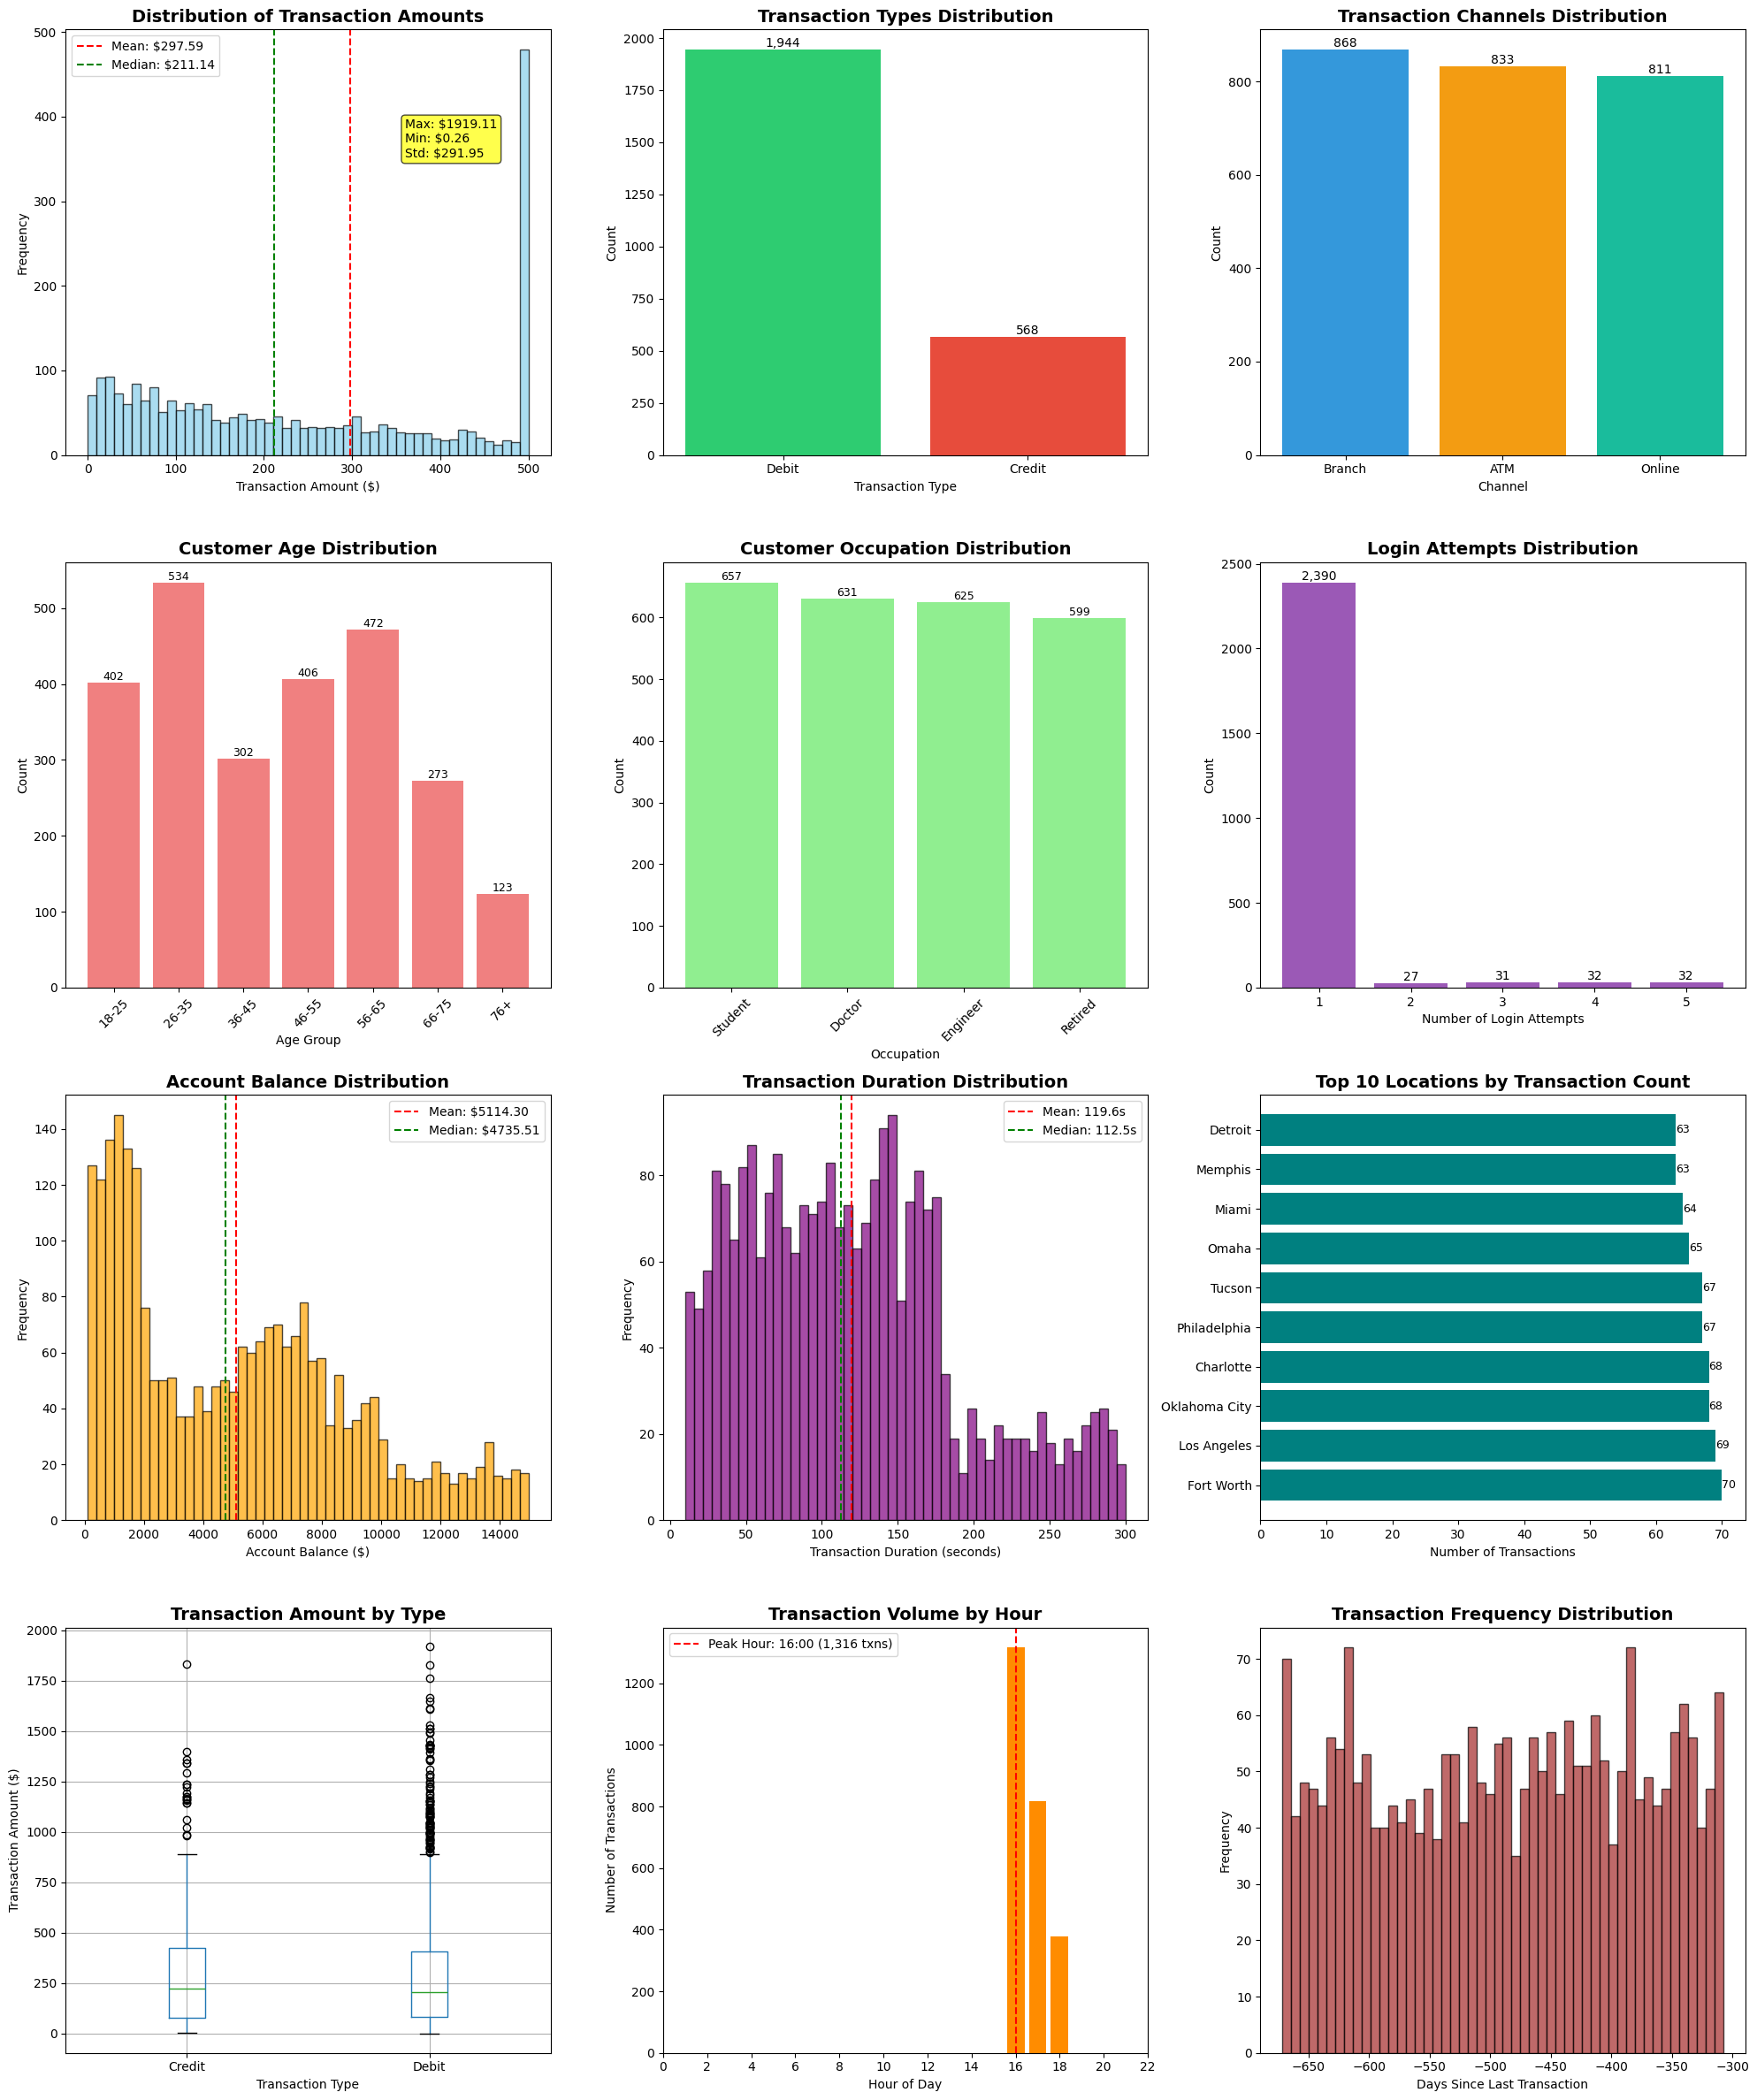

In [13]:
# Section 2: EXPLORATORY DATA ANALYSIS
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Create a figure with multiple subplots for comprehensive EDA
fig = plt.figure(figsize=(20, 24))

#Transaction Amount Distribution
ax1 = plt.subplot(4, 3, 1)
amount_data = df['TransactionAmount'].clip(upper=500)  # Clip for better visualization
ax1.hist(amount_data, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Transaction Amount ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
ax1.axvline(df['TransactionAmount'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['TransactionAmount'].mean():.2f}")
ax1.axvline(df['TransactionAmount'].median(), color='green', linestyle='--',
            label=f"Median: ${df['TransactionAmount'].median():.2f}")
ax1.legend()

# Add text box with statistics
stats_text = f"Max: ${df['TransactionAmount'].max():.2f}\nMin: ${df['TransactionAmount'].min():.2f}\nStd: ${df['TransactionAmount'].std():.2f}"
ax1.text(0.7, 0.7, stats_text, transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

#Transaction Type Distribution
ax2 = plt.subplot(4, 3, 2)
tx_type_counts = df['TransactionType'].value_counts()
bars = ax2.bar(tx_type_counts.index, tx_type_counts.values, color=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Transaction Type')
ax2.set_ylabel('Count')
ax2.set_title('Transaction Types Distribution', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Channel Distribution
ax3 = plt.subplot(4, 3, 3)
channel_counts = df['Channel'].value_counts()
bars = ax3.bar(channel_counts.index, channel_counts.values, color=['#3498db', '#f39c12', '#1abc9c'])
ax3.set_xlabel('Channel')
ax3.set_ylabel('Count')
ax3.set_title('Transaction Channels Distribution', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Customer Age Distribution
ax4 = plt.subplot(4, 3, 4)
age_bins = [18, 25, 35, 45, 55, 65, 75, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['AgeGroup'].value_counts().sort_index()
bars = ax4.bar(age_group_counts.index, age_group_counts.values, color='lightcoral')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Count')
ax4.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

#Occupation Distribution
ax5 = plt.subplot(4, 3, 5)
occupation_counts = df['CustomerOccupation'].value_counts()
bars = ax5.bar(occupation_counts.index, occupation_counts.values, color='lightgreen')
ax5.set_xlabel('Occupation')
ax5.set_ylabel('Count')
ax5.set_title('Customer Occupation Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

#Login Attempts Analysis
ax6 = plt.subplot(4, 3, 6)
login_counts = df['LoginAttempts'].value_counts().sort_index()
bars = ax6.bar(login_counts.index.astype(str), login_counts.values, color='#9b59b6')
ax6.set_xlabel('Number of Login Attempts')
ax6.set_ylabel('Count')
ax6.set_title('Login Attempts Distribution', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Account Balance Distribution
ax7 = plt.subplot(4, 3, 7)
balance_data = df['AccountBalance'].clip(upper=15000)  # Clip for better visualization
ax7.hist(balance_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax7.set_xlabel('Account Balance ($)')
ax7.set_ylabel('Frequency')
ax7.set_title('Account Balance Distribution', fontsize=14, fontweight='bold')
ax7.axvline(df['AccountBalance'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['AccountBalance'].mean():.2f}")
ax7.axvline(df['AccountBalance'].median(), color='green', linestyle='--',
            label=f"Median: ${df['AccountBalance'].median():.2f}")
ax7.legend()

#Transaction Duration Analysis
ax8 = plt.subplot(4, 3, 8)
ax8.hist(df['TransactionDuration'], bins=50, edgecolor='black', alpha=0.7, color='purple')
ax8.set_xlabel('Transaction Duration (seconds)')
ax8.set_ylabel('Frequency')
ax8.set_title('Transaction Duration Distribution', fontsize=14, fontweight='bold')
ax8.axvline(df['TransactionDuration'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['TransactionDuration'].mean():.1f}s")
ax8.axvline(df['TransactionDuration'].median(), color='green', linestyle='--',
            label=f"Median: {df['TransactionDuration'].median():.1f}s")
ax8.legend()

#Top 10 Locations by Transaction Count
ax9 = plt.subplot(4, 3, 9)
top_locations = df['Location'].value_counts().head(10)
bars = ax9.barh(range(len(top_locations)), top_locations.values, color='teal')
ax9.set_yticks(range(len(top_locations)))
ax9.set_yticklabels(top_locations.index)
ax9.set_xlabel('Number of Transactions')
ax9.set_title('Top 10 Locations by Transaction Count', fontsize=14, fontweight='bold')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax9.text(width, bar.get_y() + bar.get_height()/2., f'{int(width):,}',
             ha='left', va='center', fontsize=9)

#Transaction Amount by Type
ax10 = plt.subplot(4, 3, 10)
df.boxplot(column='TransactionAmount', by='TransactionType', ax=ax10)
ax10.set_title('Transaction Amount by Type', fontsize=14, fontweight='bold')
ax10.set_xlabel('Transaction Type')
ax10.set_ylabel('Transaction Amount ($)')
plt.suptitle('')  # Remove automatic suptitle

#Transaction Hour Distribution
ax11 = plt.subplot(4, 3, 11)
hour_counts = df['TransactionHour'].value_counts().sort_index()
bars = ax11.bar(hour_counts.index, hour_counts.values, color='darkorange')
ax11.set_xlabel('Hour of Day')
ax11.set_ylabel('Number of Transactions')
ax11.set_title('Transaction Volume by Hour', fontsize=14, fontweight='bold')
ax11.set_xticks(range(0, 24, 2))

#Highlight peak hours
peak_hour = hour_counts.idxmax()
ax11.axvline(peak_hour, color='red', linestyle='--',
             label=f"Peak Hour: {peak_hour}:00 ({hour_counts.max():,} txns)")
ax11.legend()

#Days Since Last Transaction Distribution
ax12 = plt.subplot(4, 3, 12)
days_data = df['DaysSinceLastTransaction'].clip(upper=100)
ax12.hist(days_data, bins=50, edgecolor='black', alpha=0.7, color='brown')
ax12.set_xlabel('Days Since Last Transaction')
ax12.set_ylabel('Frequency')
ax12.set_title('Transaction Frequency Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('transaction_eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()

ADVANCED PATTERN ANALYSIS

ADVANCED PATTERN ANALYSIS


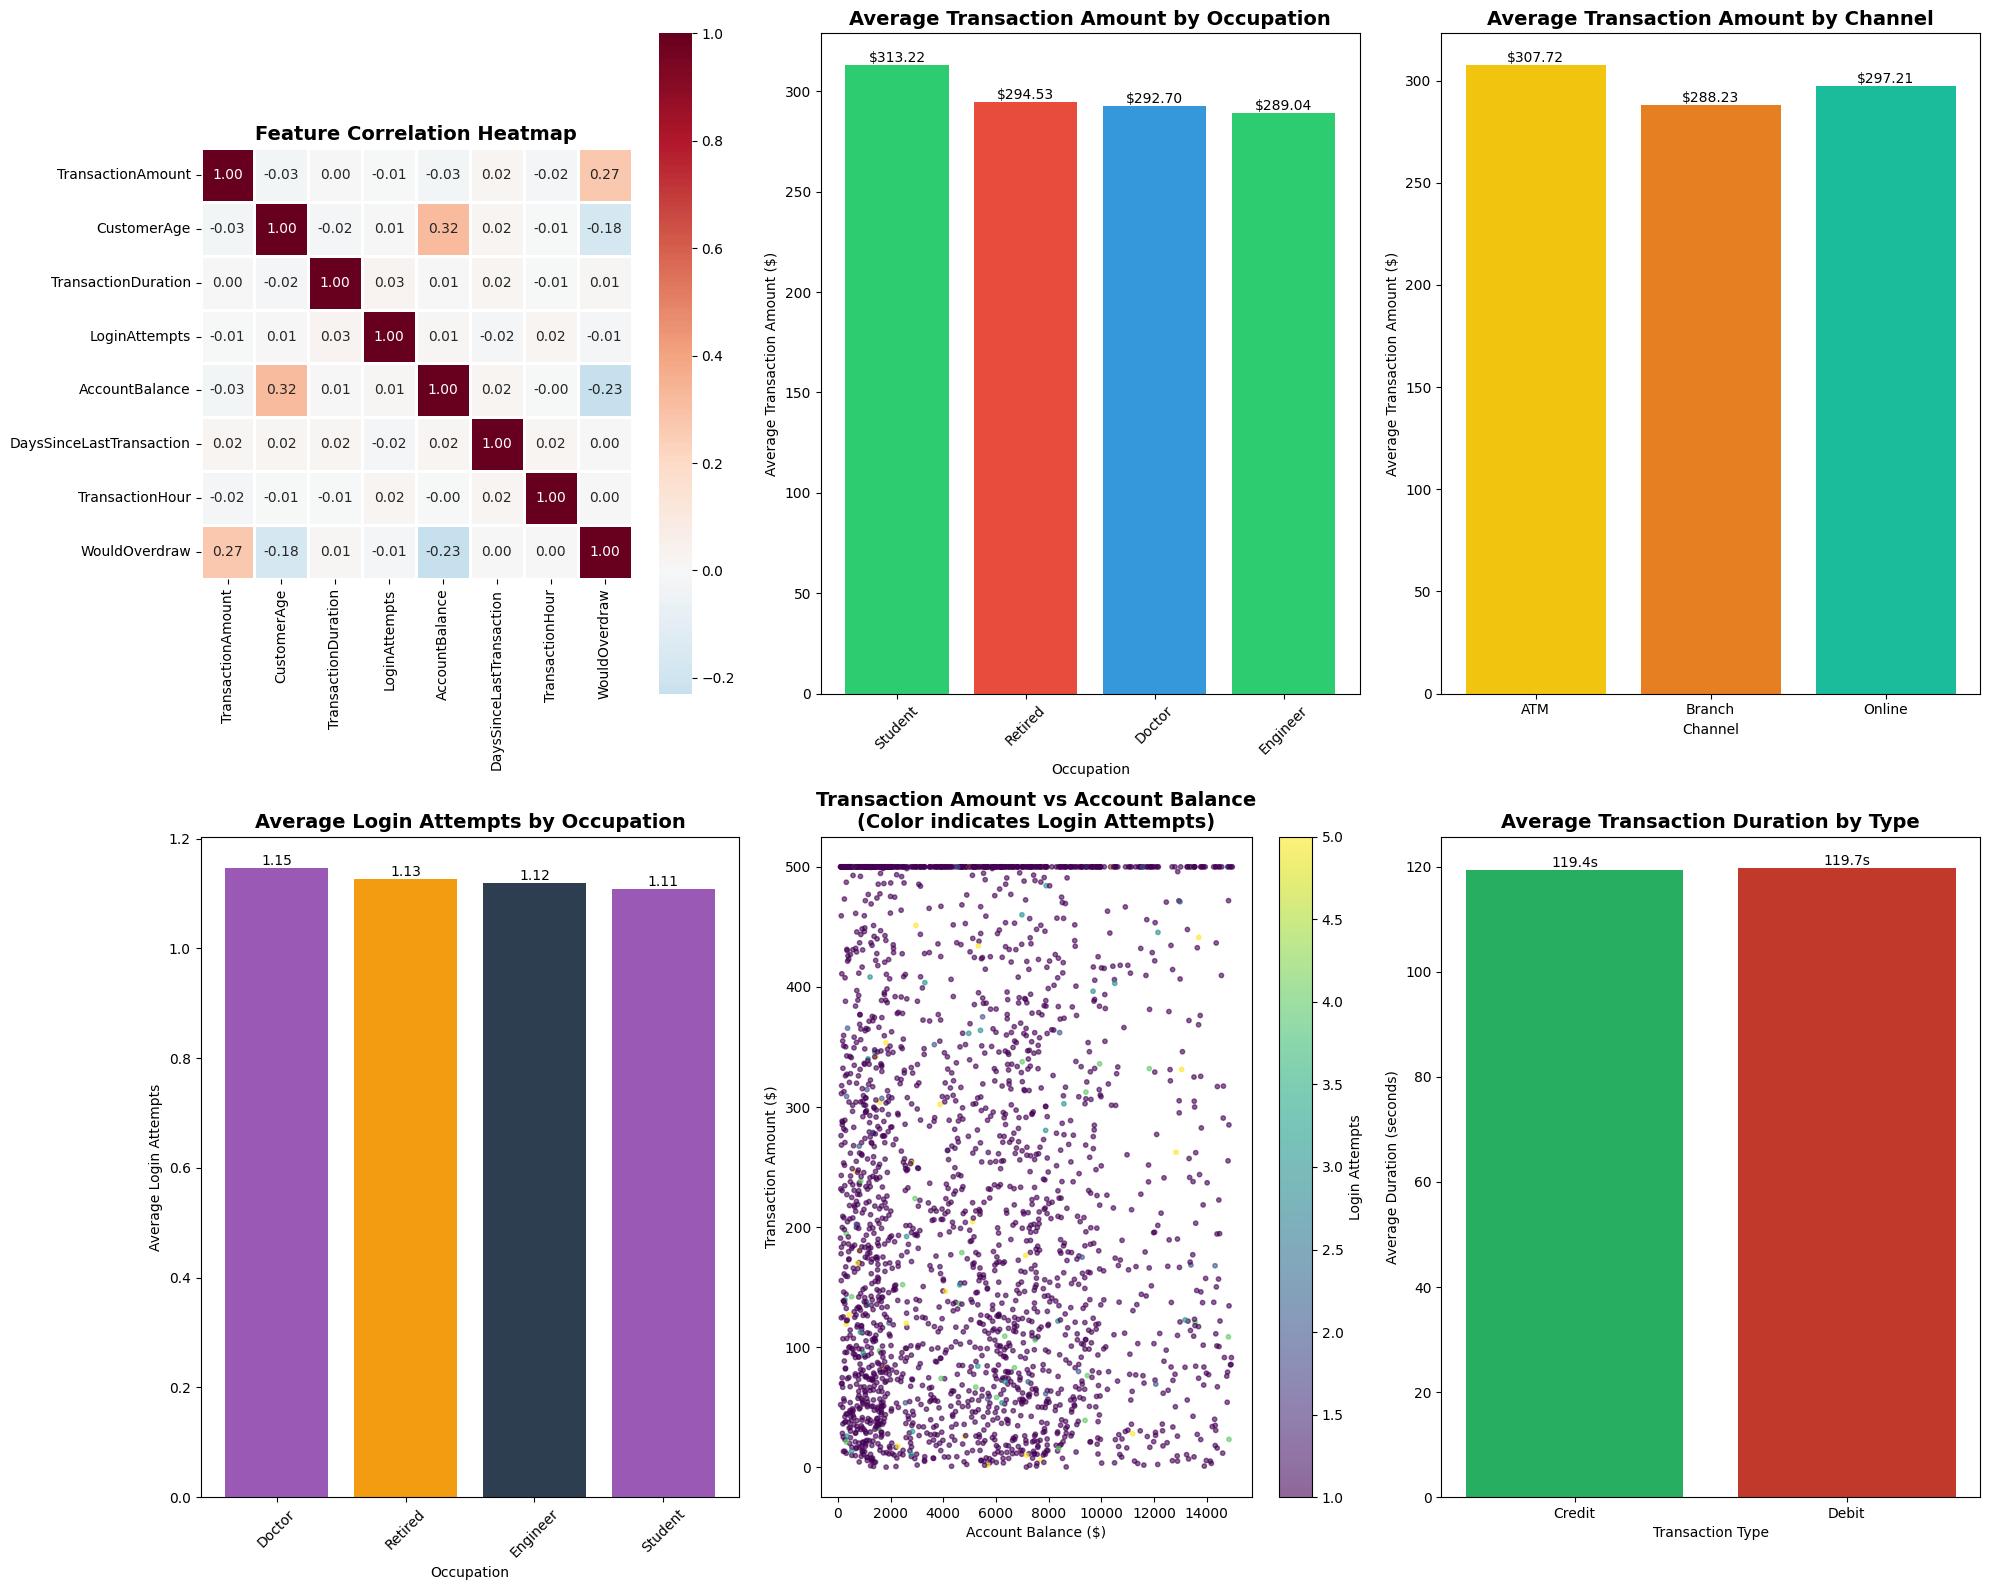

KEY INSIGHTS SUMMARY
Overall Average Transaction Amount: $297.59
Overall Median Transaction Amount: $211.14
Overall Average Login Attempts: 1.12
Transactions with >1 Login Attempts: 122 (4.9%)
Average Account Balance: $5114.30
Average Customer Age: 44.7 years
Most Common Transaction Type: Debit
Most Common Channel: Branch


In [14]:
#ADVANCED PATTERN ANALYSIS
print("=" * 50)
print("ADVANCED PATTERN ANALYSIS")
print("=" * 50)

# Create figure for advanced patterns
fig2 = plt.figure(figsize=(20, 16))

#Correlation Heatmap
ax1 = plt.subplot(2, 3, 1)
correlation_features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                        'LoginAttempts', 'AccountBalance', 'DaysSinceLastTransaction',
                        'TransactionHour', 'WouldOverdraw']
corr_matrix = df[correlation_features].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, linewidths=1, ax=ax1, fmt='.2f',
            annot_kws={'size': 10})
ax1.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

#Transaction Amount by Occupation
ax2 = plt.subplot(2, 3, 2)
occupation_amount = df.groupby('CustomerOccupation')['TransactionAmount'].agg(['mean', 'median', 'count']).round(2)
occupation_amount_sorted = occupation_amount.sort_values('mean', ascending=False)

bars = ax2.bar(occupation_amount_sorted.index, occupation_amount_sorted['mean'],
               color=['#2ecc71', '#e74c3c', '#3498db'])
ax2.set_xlabel('Occupation')
ax2.set_ylabel('Average Transaction Amount ($)')
ax2.set_title('Average Transaction Amount by Occupation', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.2f}', ha='center', va='bottom', fontsize=10)

#Transaction Amount by Channel
ax3 = plt.subplot(2, 3, 3)
channel_amount = df.groupby('Channel')['TransactionAmount'].agg(['mean', 'median', 'count']).round(2)
bars = ax3.bar(channel_amount.index, channel_amount['mean'],
               color=['#f1c40f', '#e67e22', '#1abc9c'])
ax3.set_xlabel('Channel')
ax3.set_ylabel('Average Transaction Amount ($)')
ax3.set_title('Average Transaction Amount by Channel', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.2f}', ha='center', va='bottom')

#Login Attempts by Occupation
ax4 = plt.subplot(2, 3, 4)
login_by_occupation = df.groupby('CustomerOccupation')['LoginAttempts'].mean().sort_values(ascending=False)
bars = ax4.bar(login_by_occupation.index, login_by_occupation.values,
               color=['#9b59b6', '#f39c12', '#2c3e50'])
ax4.set_xlabel('Occupation')
ax4.set_ylabel('Average Login Attempts')
ax4.set_title('Average Login Attempts by Occupation', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

#Transaction Amount vs Account Balance
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(df['AccountBalance'].clip(upper=15000),
                       df['TransactionAmount'].clip(upper=500),
                       c=df['LoginAttempts'], cmap='viridis', alpha=0.6, s=10)
ax5.set_xlabel('Account Balance ($)')
ax5.set_ylabel('Transaction Amount ($)')
ax5.set_title('Transaction Amount vs Account Balance\n(Color indicates Login Attempts)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Login Attempts')

#Transaction Duration by Type
ax6 = plt.subplot(2, 3, 6)
duration_by_type = df.groupby('TransactionType')['TransactionDuration'].mean()
bars = ax6.bar(duration_by_type.index, duration_by_type.values,
               color=['#27ae60', '#c0392b'])
ax6.set_xlabel('Transaction Type')
ax6.set_ylabel('Average Duration (seconds)')
ax6.set_title('Average Transaction Duration by Type', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}s', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('advanced_pattern_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("KEY INSIGHTS SUMMARY")
print("=" * 40)
print(f"Overall Average Transaction Amount: ${df['TransactionAmount'].mean():.2f}")
print(f"Overall Median Transaction Amount: ${df['TransactionAmount'].median():.2f}")
print(f"Overall Average Login Attempts: {df['LoginAttempts'].mean():.2f}")
print(f"Transactions with >1 Login Attempts: {df[df['LoginAttempts'] > 1].shape[0]:,} ({df[df['LoginAttempts'] > 1].shape[0]/len(df)*100:.1f}%)")
print(f"Average Account Balance: ${df['AccountBalance'].mean():.2f}")
print(f"Average Customer Age: {df['CustomerAge'].mean():.1f} years")
print(f"Most Common Transaction Type: {df['TransactionType'].mode()[0]}")
print(f"Most Common Channel: {df['Channel'].mode()[0]}")

FRAUD INDICATOR ANALYSIS

FRAUD INDICATOR ANALYSIS
Potential Fraudulent Transactions (proxy): 217
Percentage of Suspicious Transactions: 8.64%


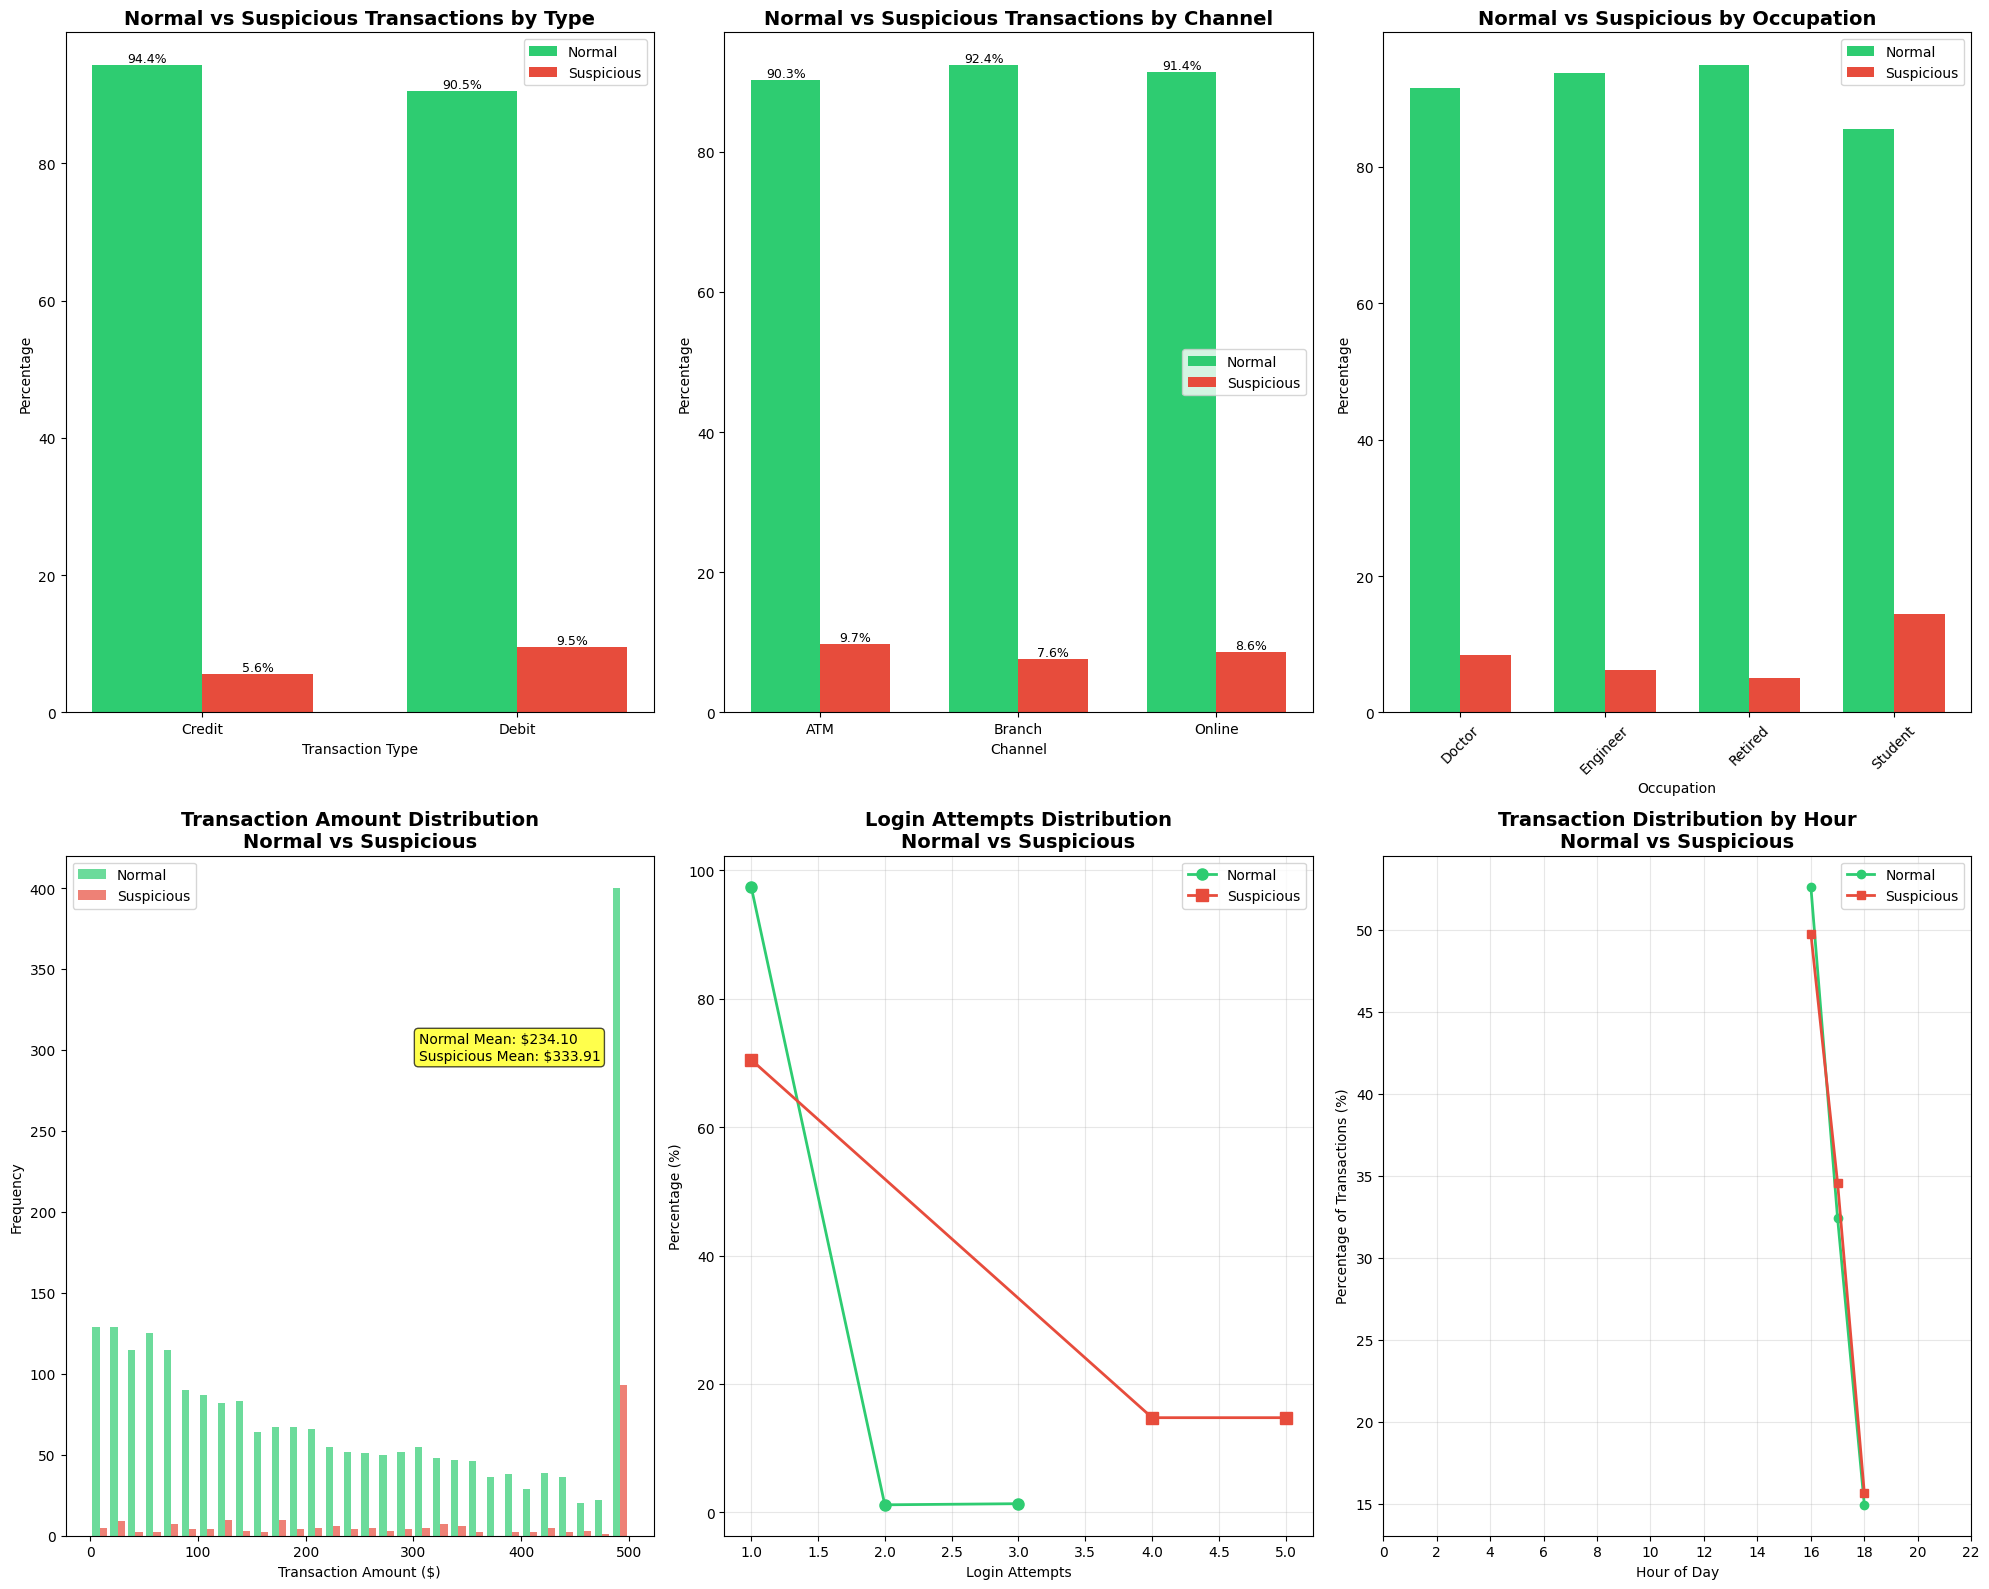

In [15]:
#FRAUD INDICATOR ANALYSIS
print("=" * 50)
print("FRAUD INDICATOR ANALYSIS")
print("=" * 50)

# Since we don't have actual fraud labels, let's create proxy fraud indicators
# based on suspicious patterns

# Define suspicious patterns (proxy for fraud)
df['Suspicious_Flag'] = 0

# High login attempts (potential brute force)
df.loc[df['LoginAttempts'] > 3, 'Suspicious_Flag'] = 1

# Unusual transaction amount (extreme outliers)
amount_threshold = df['TransactionAmount'].quantile(0.99)
df.loc[df['TransactionAmount'] > amount_threshold, 'Suspicious_Flag'] = 1

# Unusual transaction duration (very short or very long)
short_duration = df['TransactionDuration'].quantile(0.01)
long_duration = df['TransactionDuration'].quantile(0.99)
df.loc[(df['TransactionDuration'] < short_duration) |
       (df['TransactionDuration'] > long_duration), 'Suspicious_Flag'] = 1

# Unusual time (late night transactions - between 11 PM and 5 AM)
df.loc[df['TransactionHour'].between(23, 24) | df['TransactionHour'].between(0, 5), 'Suspicious_Flag'] = 1

# Transactions that would overdraw account
df.loc[df['WouldOverdraw'] == 1, 'Suspicious_Flag'] = 1

print(f"Potential Fraudulent Transactions (proxy): {df['Suspicious_Flag'].sum():,}")
print(f"Percentage of Suspicious Transactions: {df['Suspicious_Flag'].mean()*100:.2f}%")

# Create figure for fraud analysis
fig3 = plt.figure(figsize=(20, 16))

#Suspicious vs Normal Transactions by Type
ax1 = plt.subplot(2, 3, 1)
suspicious_by_type = pd.crosstab(df['TransactionType'], df['Suspicious_Flag'])
suspicious_by_type_pct = suspicious_by_type.div(suspicious_by_type.sum(axis=1), axis=0) * 100

x = np.arange(len(suspicious_by_type_pct.index))
width = 0.35

bars1 = ax1.bar(x - width/2, suspicious_by_type_pct[0], width, label='Normal', color='#2ecc71')
bars2 = ax1.bar(x + width/2, suspicious_by_type_pct[1], width, label='Suspicious', color='#e74c3c')

ax1.set_xlabel('Transaction Type')
ax1.set_ylabel('Percentage')
ax1.set_title('Normal vs Suspicious Transactions by Type', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(suspicious_by_type_pct.index)
ax1.legend()

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

#Suspicious vs Normal by Channel
ax2 = plt.subplot(2, 3, 2)
suspicious_by_channel = pd.crosstab(df['Channel'], df['Suspicious_Flag'])
suspicious_by_channel_pct = suspicious_by_channel.div(suspicious_by_channel.sum(axis=1), axis=0) * 100

x = np.arange(len(suspicious_by_channel_pct.index))
bars1 = ax2.bar(x - width/2, suspicious_by_channel_pct[0], width, label='Normal', color='#2ecc71')
bars2 = ax2.bar(x + width/2, suspicious_by_channel_pct[1], width, label='Suspicious', color='#e74c3c')

ax2.set_xlabel('Channel')
ax2.set_ylabel('Percentage')
ax2.set_title('Normal vs Suspicious Transactions by Channel', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(suspicious_by_channel_pct.index)
ax2.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

#Suspicious by Occupation
ax3 = plt.subplot(2, 3, 3)
suspicious_by_occ = pd.crosstab(df['CustomerOccupation'], df['Suspicious_Flag'])
suspicious_by_occ_pct = suspicious_by_occ.div(suspicious_by_occ.sum(axis=1), axis=0) * 100

x = np.arange(len(suspicious_by_occ_pct.index))
bars1 = ax3.bar(x - width/2, suspicious_by_occ_pct[0], width, label='Normal', color='#2ecc71')
bars2 = ax3.bar(x + width/2, suspicious_by_occ_pct[1], width, label='Suspicious', color='#e74c3c')

ax3.set_xlabel('Occupation')
ax3.set_ylabel('Percentage')
ax3.set_title('Normal vs Suspicious by Occupation', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(suspicious_by_occ_pct.index, rotation=45)
ax3.legend()

#Transaction Amount Distribution by Suspicious Flag
ax4 = plt.subplot(2, 3, 4)
suspicious_amounts = df[df['Suspicious_Flag'] == 1]['TransactionAmount'].clip(upper=500)
normal_amounts = df[df['Suspicious_Flag'] == 0]['TransactionAmount'].clip(upper=500)

ax4.hist([normal_amounts, suspicious_amounts], bins=30,
         label=['Normal', 'Suspicious'], alpha=0.7, color=['#2ecc71', '#e74c3c'])
ax4.set_xlabel('Transaction Amount ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('Transaction Amount Distribution\nNormal vs Suspicious', fontsize=14, fontweight='bold')
ax4.legend()

# Add statistics
stats_text = f"Normal Mean: ${normal_amounts.mean():.2f}\nSuspicious Mean: ${suspicious_amounts.mean():.2f}"
ax4.text(0.6, 0.7, stats_text, transform=ax4.transAxes,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

#Login Attempts by Suspicious Flag
ax5 = plt.subplot(2, 3, 5)
login_suspicious = df[df['Suspicious_Flag'] == 1]['LoginAttempts'].value_counts().sort_index()
login_normal = df[df['Suspicious_Flag'] == 0]['LoginAttempts'].value_counts().sort_index()

# Normalize to percentages
login_normal_pct = (login_normal / login_normal.sum() * 100)
login_suspicious_pct = (login_suspicious / login_suspicious.sum() * 100)

ax5.plot(login_normal_pct.index, login_normal_pct.values, 'o-', label='Normal', color='#2ecc71', linewidth=2, markersize=8)
ax5.plot(login_suspicious_pct.index, login_suspicious_pct.values, 's-', label='Suspicious', color='#e74c3c', linewidth=2, markersize=8)
ax5.set_xlabel('Login Attempts')
ax5.set_ylabel('Percentage (%)')
ax5.set_title('Login Attempts Distribution\nNormal vs Suspicious', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

#Suspicious by Hour
ax6 = plt.subplot(2, 3, 6)
suspicious_by_hour = df[df['Suspicious_Flag'] == 1].groupby('TransactionHour').size()
normal_by_hour = df[df['Suspicious_Flag'] == 0].groupby('TransactionHour').size()

#Normalize to percentages
suspicious_by_hour_pct = (suspicious_by_hour / suspicious_by_hour.sum() * 100)
normal_by_hour_pct = (normal_by_hour / normal_by_hour.sum() * 100)

ax6.plot(normal_by_hour_pct.index, normal_by_hour_pct.values, 'o-',
         label='Normal', color='#2ecc71', linewidth=2, markersize=6)
ax6.plot(suspicious_by_hour_pct.index, suspicious_by_hour_pct.values, 's-',
         label='Suspicious', color='#e74c3c', linewidth=2, markersize=6)
ax6.set_xlabel('Hour of Day')
ax6.set_ylabel('Percentage of Transactions (%)')
ax6.set_title('Transaction Distribution by Hour\nNormal vs Suspicious', fontsize=14, fontweight='bold')
ax6.set_xticks(range(0, 24, 2))
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fraud_indicator_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

PREDICTIVE MODELING
PREPARING FEATURES FOR MODELING
Features used: 13
Feature names: ['TransactionAmount_Capped', 'CustomerAge', 'TransactionDuration', 'LoginAttempts_Capped', 'AccountBalance', 'DaysSinceLastTransaction', 'TransactionHour', 'IsWeekend', 'WouldOverdraw', 'TransactionType_Encoded', 'Channel_Encoded', 'CustomerOccupation_Encoded', 'Location_Encoded']

Training set size: 2,009 transactions
Test set size: 503 transactions
Fraud rate in training: 8.66%
Fraud rate in test: 8.55%
TRAINING MULTIPLE MODELS

Training Logistic Regression...
  Accuracy: 0.9225
  ROC-AUC: 0.8923
  F1-Score: 0.6214
  Precision: 0.5333
  Recall: 0.7442

  Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96       460
  Suspicious       0.53      0.74      0.62        43

    accuracy                           0.92       503
   macro avg       0.75      0.84      0.79       503
weighted avg       0.94      0.92

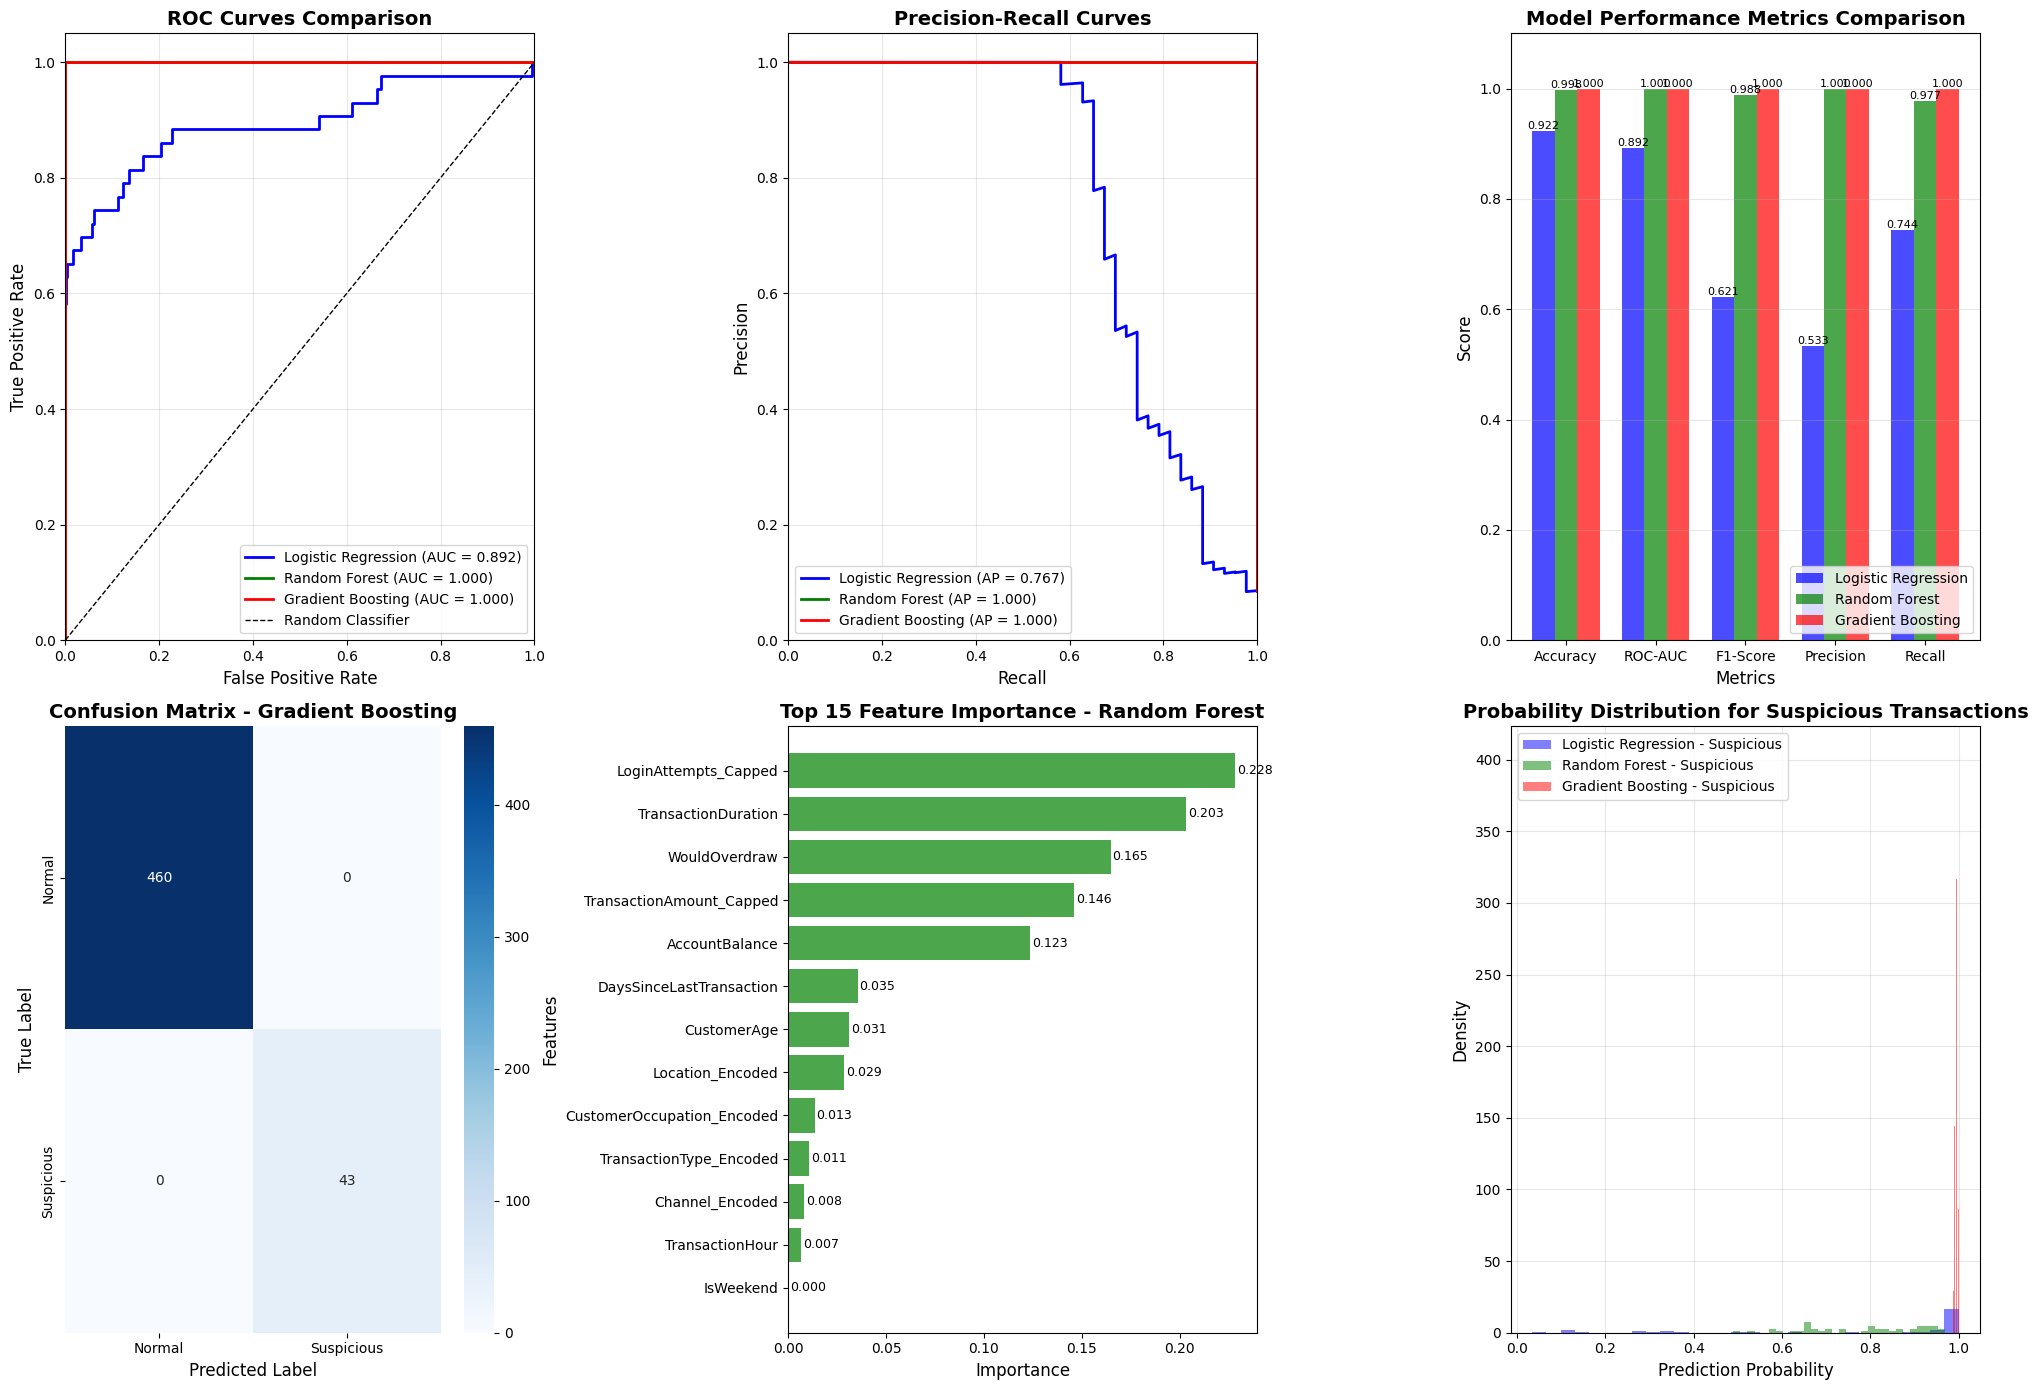

CROSS-VALIDATION RESULTS
Logistic Regression:
  CV ROC-AUC: 0.9003 (+/- 0.0271)
Random Forest:
  CV ROC-AUC: 0.9998 (+/- 0.0005)
Gradient Boosting:
  CV ROC-AUC: 1.0000 (+/- 0.0002)
BEST MODEL SELECTION
Best Model: Gradient Boosting
Performance Metrics:
  Accuracy: 1.0000
  ROC-AUC: 1.0000
  F1-Score: 1.0000
  Precision: 1.0000
  Recall: 1.0000
Best model saved as 'best_fraud_detection_model.pkl'
Scaler saved as 'scaler.pkl'
Label encoders saved as 'label_encoders.pkl'
MODEL PERFORMANCE SUMMARY
              Model Accuracy ROC-AUC F1-Score Precision Recall CV ROC-AUC (mean) CV ROC-AUC (std)
Logistic Regression   0.9225  0.8923   0.6214    0.5333 0.7442            0.9003           0.0135
      Random Forest   0.9980  1.0000   0.9882    1.0000 0.9767            0.9998           0.0002
  Gradient Boosting   1.0000  1.0000   1.0000    1.0000 1.0000            1.0000           0.0001
Model performance summary saved as 'model_performance_summary.csv'


In [16]:
#PREDICTIVE MODELING
print("=" * 50)
print("PREDICTIVE MODELING")
print("=" * 50)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Prepare features for modeling
print("PREPARING FEATURES FOR MODELING")

# Select features for modeling
feature_cols = ['TransactionAmount_Capped', 'CustomerAge', 'TransactionDuration',
                'LoginAttempts_Capped', 'AccountBalance', 'DaysSinceLastTransaction',
                'TransactionHour', 'IsWeekend', 'WouldOverdraw']

# Encode categorical variables
label_encoders = {}
categorical_cols = ['TransactionType', 'Channel', 'CustomerOccupation', 'Location']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    feature_cols.append(col + '_Encoded')
    label_encoders[col] = le

# Create feature matrix and target
X = df[feature_cols]
y = df['Suspicious_Flag']

print(f"Features used: {len(feature_cols)}")
print(f"Feature names: {feature_cols}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]:,} transactions")
print(f"Test set size: {X_test.shape[0]:,} transactions")
print(f"Fraud rate in training: {y_train.mean()*100:.2f}%")
print(f"Fraud rate in test: {y_test.mean()*100:.2f}%")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Train multiple models
print("TRAINING MULTIPLE MODELS")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = (y_pred == y_test).mean()
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")

    # Print classification report
    print(f"\n  Classification Report for {name}:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspicious']))

#Model Performance Comparison
print("MODEL PERFORMANCE COMPARISON")

# Create comparison plot
fig4, axes = plt.subplots(2, 3, figsize=(20, 14))

# Plot 1: ROC Curves
ax1 = axes[0, 0]
colors = {'Logistic Regression': 'blue', 'Random Forest': 'green', 'Gradient Boosting': 'red'}
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    ax1.plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {result["roc_auc"]:.3f})')

# Plot diagonal line
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curves
ax2 = axes[0, 1]
for name, result in results.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, result['probabilities'])
    avg_precision = average_precision_score(y_test, result['probabilities'])
    ax2.plot(recall_vals, precision_vals, color=colors[name], lw=2,
             label=f'{name} (AP = {avg_precision:.3f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

# Plot 3: Model Performance Metrics Comparison
ax3 = axes[0, 2]
metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics))
width = 0.25

for i, (name, result) in enumerate(results.items()):
    values = [result['accuracy'], result['roc_auc'], result['f1_score'],
              result['precision'], result['recall']]
    offset = (i - 1) * width
    bars = ax3.bar(x + offset, values, width, label=name, color=colors[name], alpha=0.7)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax3.set_xlabel('Metrics', fontsize=12)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Model Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend(loc="lower right")
ax3.set_ylim([0, 1.1])
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Confusion Matrix - Random Forest (Best Model)
ax4 = axes[1, 0]
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
cm = confusion_matrix(y_test, results[best_model_name]['predictions'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Normal', 'Suspicious'],
            yticklabels=['Normal', 'Suspicious'])
ax4.set_xlabel('Predicted Label', fontsize=12)
ax4.set_ylabel('True Label', fontsize=12)
ax4.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')

# Plot 5: Feature Importance - Random Forest
ax5 = axes[1, 1]
if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=True).tail(15)  # Top 15 features

    ax5.barh(feature_importance['feature'], feature_importance['importance'], color='green', alpha=0.7)
    ax5.set_xlabel('Importance', fontsize=12)
    ax5.set_ylabel('Features', fontsize=12)
    ax5.set_title('Top 15 Feature Importance - Random Forest', fontsize=14, fontweight='bold')

    # Add value labels
    for i, (_, row) in enumerate(feature_importance.iterrows()):
        ax5.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}',
                va='center', fontsize=9)

# Plot 6: Prediction Probability Distribution
ax6 = axes[1, 2]
for name, result in results.items():
    ax6.hist(result['probabilities'][y_test == 1], bins=30, alpha=0.5,
             label=f'{name} - Suspicious', color=colors[name], density=True)

ax6.set_xlabel('Prediction Probability', fontsize=12)
ax6.set_ylabel('Density', fontsize=12)
ax6.set_title('Probability Distribution for Suspicious Transactions', fontsize=14, fontweight='bold')
ax6.legend(loc="upper left")
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#Cross-Validation Results
print("CROSS-VALIDATION RESULTS")
print("=" * 40)

cv_scores = {}
for name, model in models.items():
    # Use StratifiedKFold for imbalanced data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_scores[name] = scores
    print(f"{name}:")
    print(f"  CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# 5.5 Best Model Selection
print("BEST MODEL SELECTION")
print("=" * 40)

best_model = max(results.items(), key=lambda x: x[1]['f1_score'])
print(f"Best Model: {best_model[0]}")
print(f"Performance Metrics:")
print(f"  Accuracy: {best_model[1]['accuracy']:.4f}")
print(f"  ROC-AUC: {best_model[1]['roc_auc']:.4f}")
print(f"  F1-Score: {best_model[1]['f1_score']:.4f}")
print(f"  Precision: {best_model[1]['precision']:.4f}")
print(f"  Recall: {best_model[1]['recall']:.4f}")

#Save the best model
import joblib

best_model_obj = results[best_model[0]]['model']
joblib.dump(best_model_obj, 'best_fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Best model saved as 'best_fraud_detection_model.pkl'")
print("Scaler saved as 'scaler.pkl'")
print("Label encoders saved as 'label_encoders.pkl'")

#Create a summary DataFrame
print("MODEL PERFORMANCE SUMMARY")
print("=" * 40)

summary_data = []
for name, result in results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': f"{result['accuracy']:.4f}",
        'ROC-AUC': f"{result['roc_auc']:.4f}",
        'F1-Score': f"{result['f1_score']:.4f}",
        'Precision': f"{result['precision']:.4f}",
        'Recall': f"{result['recall']:.4f}",
        'CV ROC-AUC (mean)': f"{cv_scores[name].mean():.4f}",
        'CV ROC-AUC (std)': f"{cv_scores[name].std():.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('model_performance_summary.csv', index=False)
print("Model performance summary saved as 'model_performance_summary.csv'")

PREDICTIVE ANALYSIS WITH LOGISTIC REGRESSION
PREPARING FEATURES FOR LOGISTIC REGRESSION
Features selected: 12
Feature list: ['TransactionAmount_Capped', 'CustomerAge', 'TransactionDuration', 'LoginAttempts_Capped', 'AccountBalance', 'DaysSinceLastTransaction', 'TransactionHour', 'IsWeekend', 'WouldOverdraw', 'TransactionType_Encoded', 'Channel_Encoded', 'CustomerOccupation_Encoded']
Target Distribution:
Normal Transactions: 2,295 (91.36%)
Suspicious Transactions: 217 (8.64%)
Dataset Split:
 Training set: 2,009 transactions
 Test set: 503 transactions
Features scaled using StandardScaler
HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
 Testing 24 parameter combinations...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits

 Best Parameters: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
 Best Cross-Validation ROC-AUC: 0.8996
LOGISTIC REGRESSION MODEL EVALUATION

 PERFORMANCE METRICS:
   Accuracy:  0.9264 (92.64%)
   ROC-AUC:   0.89

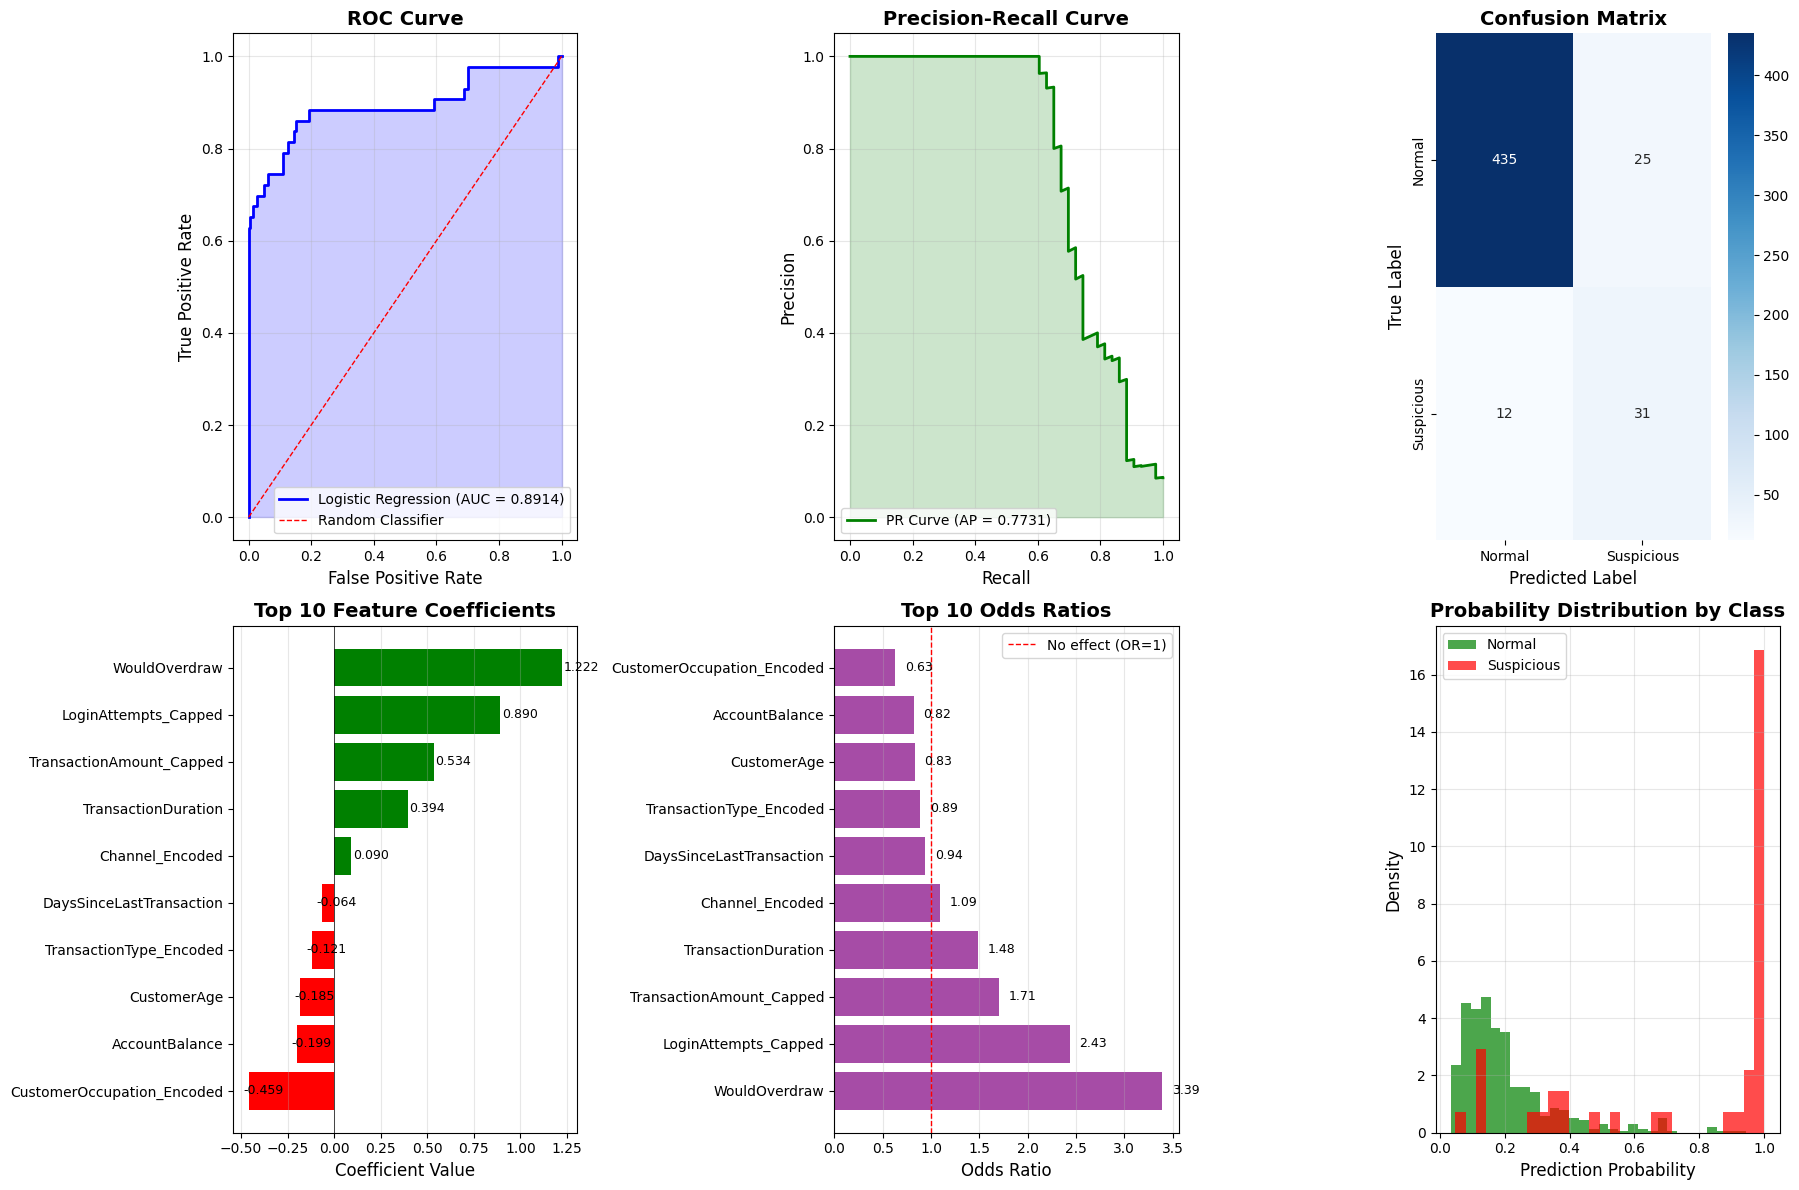

THRESHOLD OPTIMIZATION FOR BUSINESS NEEDS

 Performance at Different Thresholds:
 Threshold  Accuracy  Precision  Recall     F1  False_Positives  False_Negatives
      0.10    0.2922     0.1058  0.9767 0.1909              355                1
      0.15    0.4930     0.1319  0.8837 0.2296              250                5
      0.20    0.6640     0.1881  0.8837 0.3102              164                5
      0.25    0.7594     0.2468  0.8837 0.3858              116                5
      0.30    0.8330     0.3217  0.8605 0.4684               78                6
      0.35    0.8608     0.3608  0.8140 0.5000               62                8
      0.40    0.8926     0.4267  0.7442 0.5424               43               11
      0.45    0.9165     0.5079  0.7442 0.6038               31               11
      0.50    0.9264     0.5536  0.7209 0.6263               25               12
      0.55    0.9324     0.5849  0.7209 0.6458               22               12
      0.60    0.9384     0.6

In [23]:
#PREDICTIVE ANALYSIS WITH LOGISTIC REGRESSION
print("=" * 50)
print("PREDICTIVE ANALYSIS WITH LOGISTIC REGRESSION")
print("=" * 50)

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score, f1_score,
                             precision_score, recall_score, accuracy_score)
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#PREPARE FEATURES FOR MODELING
print("PREPARING FEATURES FOR LOGISTIC REGRESSION")

#Select features for modeling
feature_cols = ['TransactionAmount_Capped', 'CustomerAge', 'TransactionDuration',
                'LoginAttempts_Capped', 'AccountBalance', 'DaysSinceLastTransaction',
                'TransactionHour', 'IsWeekend', 'WouldOverdraw']

#Encode categorical variables
label_encoders = {}
categorical_cols = ['TransactionType', 'Channel', 'CustomerOccupation']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_Encoded'] = le.fit_transform(df[col])
    feature_cols.append(col + '_Encoded')
    label_encoders[col] = le

# Note: Not including 'Location' to avoid too many dummy variables

print(f"Features selected: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

# Create feature matrix and target
X = df[feature_cols]
y = df['Suspicious_Flag']

print(f"Target Distribution:")
print(f"Normal Transactions: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"Suspicious Transactions: {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")

# Split the data (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset Split:")
print(f" Training set: {X_train.shape[0]:,} transactions")
print(f" Test set: {X_test.shape[0]:,} transactions")

# Scale the features (crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

#HYPERPARAMETER TUNING
print("HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION")

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'solver': ['liblinear', 'saga', 'lbfgs'],
    'class_weight': ['balanced', None],
    'max_iter': [1000, 2000]
}

# Filter valid combinations
valid_params = []
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    for penalty in ['l1', 'l2']:
        for class_weight in ['balanced', None]:
            valid_params.append({
                'C': C,
                'penalty': penalty,
                'solver': 'liblinear',
                'class_weight': class_weight,
                'max_iter': 1000
            })

print(f" Testing {len(valid_params)} parameter combinations...")

# Grid search with cross-validation
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Use best model
best_lr = grid_search.best_estimator_

#MODEL EVALUATION
print("LOGISTIC REGRESSION MODEL EVALUATION")

# Make predictions
y_pred = best_lr.predict(X_test_scaled)
y_pred_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"\n PERFORMANCE METRICS:")
print(f"   Accuracy:  {accuracy:.4f} ({(accuracy*100):.2f}%)")
print(f"   ROC-AUC:   {roc_auc:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")

# Cross-validation scores
cv_scores = cross_val_score(
    best_lr, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc'
)

print(f"\n 5-FOLD CROSS-VALIDATION ROC-AUC:")
print(f"   Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"   Individual folds: {[f'{score:.4f}' for score in cv_scores]}")

# 5.4 DETAILED CLASSIFICATION REPORT
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Suspicious']))

#CONFUSION MATRIX
print("CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"               Predicted")
print(f"               Normal  Suspicious")
print(f"Actual Normal   {cm[0,0]:6d}   {cm[0,1]:6d}")
print(f"       Suspicious {cm[1,0]:6d}   {cm[1,1]:6d}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed Breakdown:")
print(f"   True Negatives (Correctly identified normal): {tn:,}")
print(f"   False Positives (Normal flagged as suspicious): {fp:,}")
print(f"   False Negatives (Suspicious missed): {fn:,}")
print(f"   True Positives (Correctly identified suspicious): {tp:,}")
print(f"\n   False Positive Rate: {fp/(fp+tn)*100:.2f}%")
print(f"   False Negative Rate: {fn/(fn+tp)*100:.2f}%")

#FEATURE IMPORTANCE (COEFFICIENTS)
print("FEATURE IMPORTANCE ANALYSIS")

# Get coefficients
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': best_lr.coef_[0],
    'Abs_Coefficient': np.abs(best_lr.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

# Calculate odds ratios
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])
coefficients['Impact'] = ['Increases Risk' if c > 0 else 'Decreases Risk' for c in coefficients['Coefficient']]

print("\n Top 15 Most Important Features:")
print(coefficients.head(15).to_string(index=False))

print("\nInterpretation (Odds Ratios):")
for _, row in coefficients.head(10).iterrows():
    impact = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"   • {row['Feature']}: 1-unit increase {impact} fraud odds by {abs(row['Odds_Ratio']-1)*100:.1f}%")

#VISUALIZATION
print("GENERATING VISUALIZATIONS")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: ROC Curve
ax1 = axes[0, 0]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random Classifier')
ax1.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontweight='bold', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Plot 2: Precision-Recall Curve
ax2 = axes[0, 1]
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)
ax2.plot(recall_vals, precision_vals, 'g-', linewidth=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
ax2.fill_between(recall_vals, precision_vals, alpha=0.2, color='green')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontweight='bold', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix Heatmap
ax3 = axes[0, 2]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Normal', 'Suspicious'],
            yticklabels=['Normal', 'Suspicious'])
ax3.set_xlabel('Predicted Label', fontsize=12)
ax3.set_ylabel('True Label', fontsize=12)
ax3.set_title('Confusion Matrix', fontweight='bold', fontsize=14)

# Plot 4: Feature Importance (Top 10)
ax4 = axes[1, 0]
top_features = coefficients.head(10).sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
bars = ax4.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_xlabel('Coefficient Value', fontsize=12)
ax4.set_title('Top 10 Feature Coefficients', fontweight='bold', fontsize=14)
ax4.grid(True, alpha=0.3, axis='x')

# Add value labels
for bar, coef in zip(bars, top_features['Coefficient']):
    ax4.text(coef + (0.01 if coef > 0 else -0.03), bar.get_y() + bar.get_height()/2,
             f'{coef:.3f}', va='center', fontsize=9)

# Plot 5: Odds Ratios
ax5 = axes[1, 1]
top_odds = coefficients.head(10).sort_values('Odds_Ratio', ascending=False)
bars = ax5.barh(top_odds['Feature'], top_odds['Odds_Ratio'], color='purple', alpha=0.7)
ax5.axvline(x=1, color='red', linestyle='--', linewidth=1, label='No effect (OR=1)')
ax5.set_xlabel('Odds Ratio', fontsize=12)
ax5.set_title('Top 10 Odds Ratios', fontweight='bold', fontsize=14)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='x')

for bar, or_val in zip(bars, top_odds['Odds_Ratio']):
    ax5.text(or_val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{or_val:.2f}', va='center', fontsize=9)

# Plot 6: Probability Distribution
ax6 = axes[1, 2]
ax6.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, color='green',
         label='Normal', density=True)
ax6.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, color='red',
         label='Suspicious', density=True)
ax6.set_xlabel('Prediction Probability', fontsize=12)
ax6.set_ylabel('Density', fontsize=12)
ax6.set_title('Probability Distribution by Class', fontweight='bold', fontsize=14)
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

#THRESHOLD OPTIMIZATION
print("THRESHOLD OPTIMIZATION FOR BUSINESS NEEDS")

# Calculate metrics at different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)

    # Calculate metrics
    tn_th, fp_th, fn_th, tp_th = confusion_matrix(y_test, y_pred_thresh).ravel()

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_thresh),
        'Precision': precision_score(y_test, y_pred_thresh),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh),
        'False_Positives': fp_th,
        'False_Negatives': fn_th
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n Performance at Different Thresholds:")
print(threshold_df.round(4).to_string(index=False))

# Find optimal threshold for different business needs
max_f1_idx = threshold_df['F1'].idxmax()
max_precision_idx = threshold_df['Precision'].idxmax()
max_recall_idx = threshold_df['Recall'].idxmax()

print(f"\n Optimal threshold for F1-Score: {threshold_df.loc[max_f1_idx, 'Threshold']:.2f}")
print(f" Optimal threshold for Precision: {threshold_df.loc[max_precision_idx, 'Threshold']:.2f}")
print(f" Optimal threshold for Recall: {threshold_df.loc[max_recall_idx, 'Threshold']:.2f}")

#SAVE MODEL AND PREPROCESSING OBJECTS
print("SAVING MODEL AND ARTIFACTS")

import joblib
import os

# Create models directory
os.makedirs('logistic_regression_model', exist_ok=True)

# Save model and preprocessing objects
joblib.dump(best_lr, 'logistic_regression_model/best_logistic_regression.pkl')
joblib.dump(scaler, 'logistic_regression_model/scaler.pkl')
joblib.dump(label_encoders, 'logistic_regression_model/label_encoders.pkl')
joblib.dump(feature_cols, 'logistic_regression_model/feature_columns.pkl')

print(" Model saved to 'logistic_regression_model/best_logistic_regression.pkl'")
print(" Scaler saved to 'logistic_regression_model/scaler.pkl'")
print(" Label encoders saved to 'logistic_regression_model/label_encoders.pkl'")
print(" Feature columns saved to 'logistic_regression_model/feature_columns.pkl'")

#CREATE PREDICTION FUNCTION
print("PREDICTION FUNCTION FOR NEW TRANSACTIONS")

def predict_fraud(new_transaction_df, model, scaler, feature_cols, label_encoders):
    """
    Predict fraud probability for new transactions

    Parameters:
    -----------
    new_transaction_df : DataFrame with same features as training data
    model : trained LogisticRegression model
    scaler : fitted StandardScaler
    feature_cols : list of feature names
    label_encoders : dict of fitted LabelEncoders for categorical variables

    Returns:
    --------
    DataFrame with predictions and probabilities
    """

    # Prepare features (same as training)
    X_new = new_transaction_df[feature_cols].copy()

    # Scale features
    X_new_scaled = scaler.transform(X_new)

    # Predict
    predictions = model.predict(X_new_scaled)
    probabilities = model.predict_proba(X_new_scaled)

    # Create results DataFrame
    results = new_transaction_df.copy()
    results['Predicted_Class'] = ['Suspicious' if p == 1 else 'Normal' for p in predictions]
    results['Fraud_Probability'] = probabilities[:, 1]
    results['Risk_Level'] = pd.cut(results['Fraud_Probability'],
                                   bins=[0, 0.3, 0.7, 1.0],
                                   labels=['Low', 'Medium', 'High'])

    return results

print(" Prediction function 'predict_fraud()' created successfully!")



#FINAL SUMMARY
print("FINAL MODEL SUMMARY TABLE")
print("=" * 50)

summary_table = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'F1-Score', 'Precision', 'Recall',
               'CV Mean ROC-AUC', 'CV Std ROC-AUC', 'Training Time'],
    'Value': [f'{accuracy:.4f}', f'{roc_auc:.4f}', f'{f1:.4f}',
              f'{precision:.4f}', f'{recall:.4f}',
              f'{cv_scores.mean():.4f}', f'{cv_scores.std():.4f}',
              f'{grid_search.refit_time_:.2f}s']
})

print(summary_table.to_string(index=False))
print("\n" + "=" * 50)
print(" LOGISTIC REGRESSION ANALYSIS COMPLETE!")
print("=" * 50)